In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix, f1_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# load csv file

In [2]:
df = pd.read_csv("shop_smart_ecommerce.csv")
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


# Overview of Dataset

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  str    
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType              12330 no

# Handel Missing and duplicates Values

In [4]:
df.isnull().sum(), df.duplicated().sum()

df = df.drop_duplicates()



# Data Preprocessing

In [5]:
cols = ["Month", "VisitorType"]

hoe = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")
encode = hoe.fit_transform(df[cols])
encode_df = pd.DataFrame(encode, columns= hoe.get_feature_names_out(cols), index=df.index)
df = pd.concat([df.drop(columns = cols), encode_df], axis=1)

In [6]:
bool_maping = {False:0,
               True:1
              }

df["Weekend"]= df["Weekend"].map(bool_maping)
df["Revenue"] =df["Revenue"].map(bool_maping)

# Exploratory Data Analysis

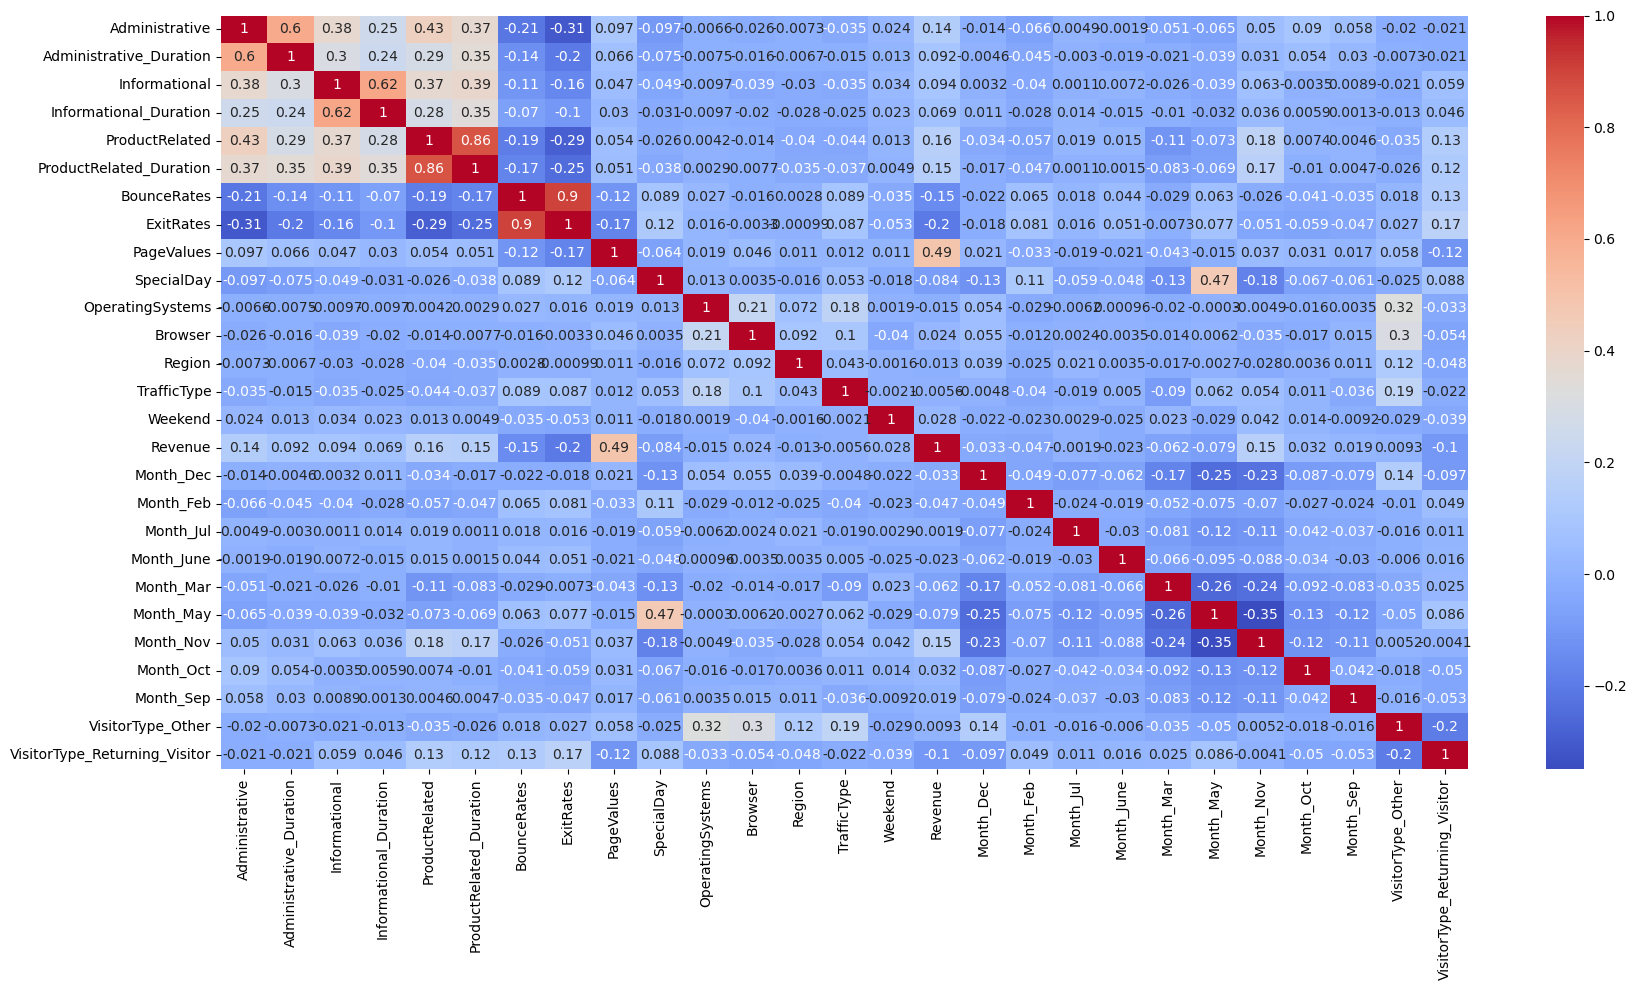

In [7]:
data = df.select_dtypes(include='number')
correlation = data.corr()
plt.figure(figsize=(18,10))
sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)
plt.tight_layout()
plt.show()

# Feature Selection

In [8]:
x=df.drop(columns="Revenue")
y=df["Revenue"]

# Train Test Split 

In [9]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state=42)

# Make Pipeline 

In [10]:
pipe = Pipeline([("classifier", DecisionTreeClassifier(random_state=42))])

# GridSearchCV for hyperparameter tuning

In [11]:

param_grid={
    "classifier__max_depth": [4, 6, 8, None],
    "classifier__min_samples_split": [2, 5, 10, 20],
    "classifier__ccp_alpha": [0.0, 0.001, 0.01]
}

Gd =  GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring="f1"
                  )

Gd.fit(x_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__ccp_alpha': [0.0, 0.001, ...], 'classifier__max_depth': [4, 6, ...], 'classifier__min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and pa

In [12]:
y_pred = Gd.predict(x_test)
print("Accuraxy: ", accuracy_score(y_test, y_pred))
print("precision: ", precision_score(y_test, y_pred))
print("f1_Score: ", f1_score(y_test, y_pred))
print("Confussion Matrix: ", confusion_matrix(y_test, y_pred))

Accuraxy:  0.9000409668168783
precision:  0.6766467065868264
f1_Score:  0.6494252873563219
Confussion Matrix:  [[1971  108]
 [ 136  226]]


In [13]:
print("Best F1: ", Gd.best_score_)
print("Best params: ", Gd.best_params_)

Best F1:  0.6631076012625288
Best params:  {'classifier__ccp_alpha': 0.001, 'classifier__max_depth': 6, 'classifier__min_samples_split': 2}


# Visualization

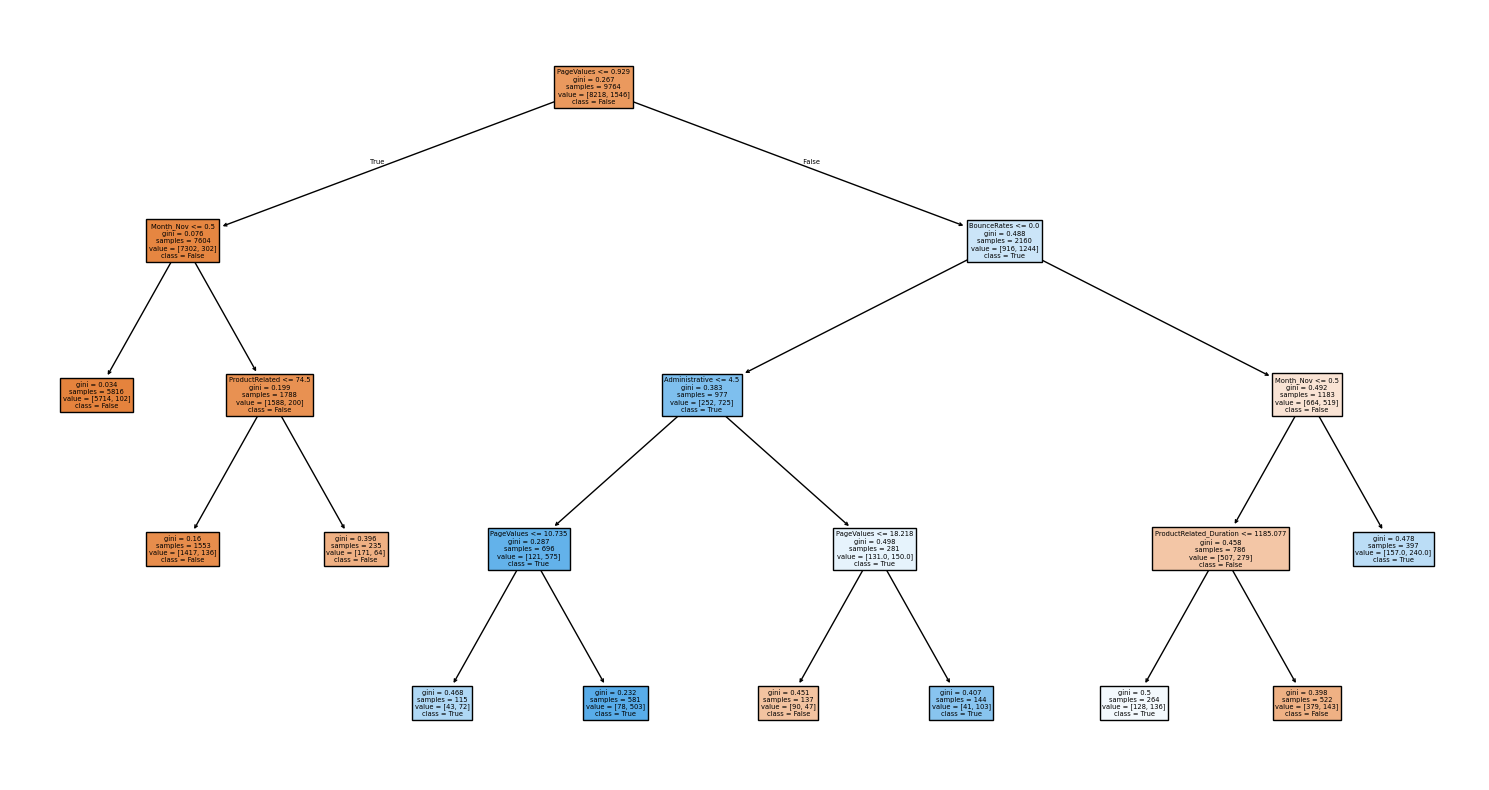

In [14]:
from sklearn.tree import plot_tree
model = DecisionTreeClassifier(ccp_alpha=0.001, 
                               max_depth=6,
                               min_samples_split=2,
                               random_state=42)
model.fit(x_train, y_train)
plt.figure(figsize=(15, 8))
plot_tree(
    model,
    feature_names=x.columns,
    class_names=["False", "True"],
    filled=True
)
plt.tight_layout()
plt.show()



